In [65]:
# Function to calculate proportion of top/bottom slices with low/no signal (.nii.gz format)
import os
import nibabel as nib
import numpy as np
from glob import glob
import pandas as pd
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt
import contextlib
import joblib

In [71]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """
    Enables parallel jobs to run and display of a tqdm progress bar.

    Parameters:
    -----------
    tqdm_object : tqdm
        The tqdm progress bar instance to be updated.

    """
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [72]:
def load_nifti(file_path):
    img = nib.load(file_path)
    arr = img.get_fdata()
    return arr

In [73]:
def show_random_top_bottom_pairs(target_files, i, to_plot = True):
    test =  load_nifti(target_files[i])
    test_bottom = test[0,:,:]
    test_top = test[-1,:,:]
    binary_bottom = test_bottom > threshold_otsu(test_bottom)
    binary_top = test_top > threshold_otsu(test_top)
    image_size = test_bottom.shape[0] * test_bottom.shape[1]
    top_vasculature_percent = 100*np.sum(binary_top)/image_size
    bottom_vasculature_percent = 100*np.sum(binary_bottom)/image_size
    if to_plot:
        fig, ax = plt.subplots(ncols = 2, nrows=2, figsize=(2, 2), gridspec_kw={"hspace": 0.3})
        ax[0, 0].imshow(test_bottom, cmap="gray")
        ax[0,1].imshow(binary_bottom)
        ax[1, 0].imshow(test_top, cmap="gray")
        ax[1,1].imshow(binary_top)
        fig.text(0.5, 0.98, f"Bottom, {bottom_vasculature_percent:.2f}% Vasculature",
                ha="center", va="top", fontsize=6)
        fig.text(0.5, 0.52, f"Top, {top_vasculature_percent:.2f}% Vasculature",
                ha="center", va="top", fontsize=6)

        print(bottom_vasculature_percent, top_vasculature_percent)
        for a in ax.flat:
            a.axis("off")
        plt.tight_layout()
        plt.savefig(f"top_bottom_{i}.pdf")
        plt.savefig(f"top_bottom_{i}.png")
        plt.show()
    return pd.DataFrame({
        "i": i,
        "top_vasculature_percent": top_vasculature_percent,
        "bottom_vasculature_percent": bottom_vasculature_percent
    }, index=[0])


In [74]:
train_dir = r'Z:/OLD members/Rappez/VascuMAP_3D/training_data'
input_dir = os.path.join(train_dir, 'input')
target_dir = os.path.join(train_dir, 'target')

input_files = sorted(glob(os.path.join(input_dir, '*.nii.gz')))
target_files = sorted(glob(os.path.join(target_dir, '*.nii.gz')))
assert len(input_files) == len(target_files), 'Input and target file counts do not match.'

print(f'Input: {len(input_files)} files')
print(f'Target: {len(target_files)} files')

all_outputs = [] 
for i in np.random.choice(len(target_files), size=15, replace=False):
    all_outputs.append(show_random_top_bottom_pairs(target_files, i=i, to_plot=False))
combined = pd.concat(all_outputs)

Input: 6107 files
Target: 6107 files


In [77]:

from joblib import Parallel, delayed
from tqdm import tqdm


with tqdm_joblib(tqdm(desc="Image Analysis", total=len(input_files))) as progress_bar:
    output = Parallel(n_jobs=2)(delayed(show_random_top_bottom_pairs)(target_files, i=i, to_plot=False) for i in range(len(input_files)))

Image Analysis: 100%|██████████| 6107/6107 [08:28<00:00, 12.01it/s]


In [78]:
combined = pd.concat(output)
combined.to_csv("top_bottom_vasculature_proportions.csv", index=False)

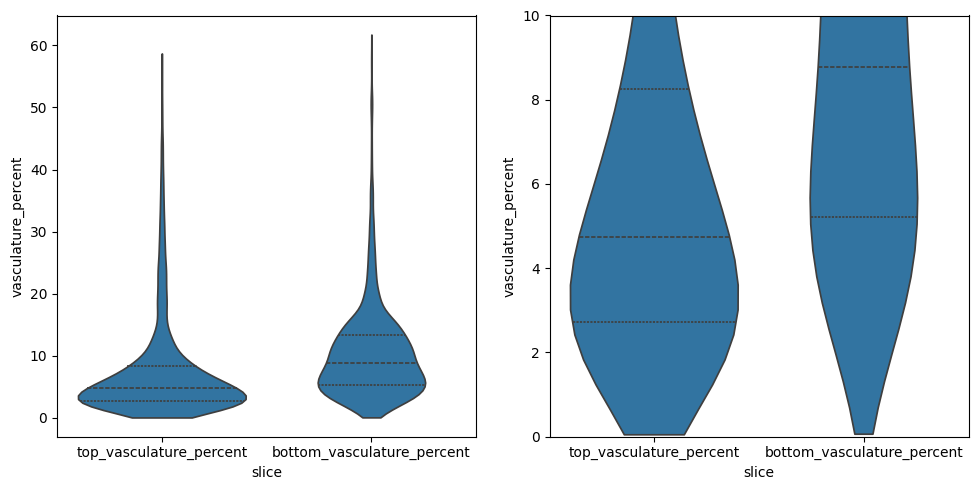

In [88]:
import seaborn as sns

long_df = combined.melt(
    value_vars=["top_vasculature_percent", "bottom_vasculature_percent"],
    var_name="slice",
    value_name="vasculature_percent",
)
fig, ax = plt.subplots(ncols = 2, figsize=(10, 5))
sns.violinplot(data=long_df, x="slice", y="vasculature_percent", inner="quartile", cut=0, ax=ax[0])
sns.violinplot(data=long_df, x="slice", y="vasculature_percent", inner="quartile", cut=0, ax=ax[1])
ax[1].set_ylim(0,10)
plt.tight_layout()
plt.savefig("vasculature_proportions_violin_plots.pdf")
plt.savefig("vasculature_proportions_violin_plots.png")
